# FIFA World Cup 2026 – Analytic Task 2 Only

## Analytic question
Do forwards have higher shooting accuracy than midfielders among players with meaningful playing time and shooting involvement?

**H0:** The mean shooting accuracy is equal for forwards and midfielders.

**H1:** The mean shooting accuracy differs between forwards and midfielders.

This notebook contains only Task 2 and uses:
- `player_standard.csv`
- `player_shooting.csv`


## 1. Import libraries and helper functions


In [10]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

RANDOM_STATE = 42
ALPHA = 0.05

def make_unique(columns):
    counts = {}
    result = []
    for col in columns:
        col = str(col).replace("▼", "").strip()
        if col in counts:
            counts[col] += 1
            result.append(f"{col}.{counts[col]}")
        else:
            counts[col] = 0
            result.append(col)
    return result

def read_fbref_csv(path):
    df = pd.read_csv(path, header=1)
    df.columns = make_unique(df.columns)
    df = df.loc[:, ~df.columns.astype(str).str.match("^Unnamed")]
    for c in df.columns:
        if c not in ["Player", "Pos", "Squad", "Club", "Matches"]:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df.dropna(how="all").reset_index(drop=True)

def ci_mean(x, confidence=0.95):
    x = pd.Series(x).dropna().astype(float)
    n = len(x)
    mean = x.mean()
    sd = x.std(ddof=1)
    se = sd / np.sqrt(n)
    tcrit = stats.t.ppf((1 + confidence) / 2, n - 1)
    return pd.Series({
        "n": n,
        "mean": mean,
        "sd": sd,
        "lower": mean - tcrit * se,
        "upper": mean + tcrit * se
    })

def welch_ci_diff(x1, x2, confidence=0.95):
    x1 = pd.Series(x1).dropna().astype(float)
    x2 = pd.Series(x2).dropna().astype(float)
    n1, n2 = len(x1), len(x2)
    m1, m2 = x1.mean(), x2.mean()
    v1, v2 = x1.var(ddof=1), x2.var(ddof=1)
    se = np.sqrt(v1/n1 + v2/n2)
    df = (v1/n1 + v2/n2)**2 / (((v1/n1)**2)/(n1-1) + ((v2/n2)**2)/(n2-1))
    tcrit = stats.t.ppf((1 + confidence) / 2, df)
    diff = m1 - m2
    return pd.Series({
        "difference": diff,
        "lower": diff - tcrit * se,
        "upper": diff + tcrit * se,
        "df": df
    })

print("Setup complete.")


Setup complete.


## 2. Load the two raw FBref datasets


In [11]:
player_standard = read_fbref_csv("player_standard.csv")
player_shooting = read_fbref_csv("player_shooting.csv")

print("player_standard:", player_standard.shape)
print("player_shooting:", player_shooting.shape)

display(player_standard.head())
display(player_shooting.head())


player_standard: (1039, 26)
player_shooting: (1039, 19)


,Rk,Player,Pos,Squad,Age,Club,Born,MP,Starts,Min,...,PKatt,CrdY,CrdR,Gls.1,Ast.1,G+A.1,G-PK.1,G+A-PK,Matches,-9999
0,1,Brenden Aaronson,MF,us USA,25,1.eng Leeds United,2000,1,1,76,...,0,0,0,0.0,0.0,0.0,0.0,0.0,Matches,NaN
1,2,Thelo Aasgaard,MF,no Norway,24,1.sct Rangers,2002,1,1,90,...,0,0,0,1.0,0.0,1.0,1.0,1.0,Matches,NaN
2,3,Hamza Abdelkarim,FW,eg Egypt,18,4.es Barcelona B,2008,4,0,60,...,0,0,0,0.0,0.0,0.0,0.0,0.0,Matches,NaN
3,4,Hossam Abdelmaguid,DF,eg Egypt,25,1.eg Zamalek SC,2001,2,0,59,...,0,0,0,0.0,0.0,0.0,0.0,0.0,Matches,NaN
4,5,Mohamed Abdelmonem,DF,eg Egypt,27,1.fr Nice,1999,2,1,14,...,0,0,0,0.0,0.0,0.0,0.0,0.0,Matches,NaN


,Rk,Player,Pos,Squad,Age,Born,90s,Gls,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,PK,PKatt,Matches,-9999
0,1,Brenden Aaronson,MF,us USA,25,2000,0.8,0,3,1,33.3,3.55,1.18,0.0,0.0,0,0,Matches,NaN
1,2,Thelo Aasgaard,MF,no Norway,24,2002,1.0,1,2,1,50.0,2.00,1.00,0.5,1.0,0,0,Matches,NaN
2,3,Hamza Abdelkarim,FW,eg Egypt,18,2008,0.7,0,0,0,NaN,0.00,0.00,NaN,NaN,0,0,Matches,NaN
3,4,Hossam Abdelmaguid,DF,eg Egypt,25,2001,0.7,0,0,0,NaN,0.00,0.00,NaN,NaN,0,0,Matches,NaN
4,5,Mohamed Abdelmonem,DF,eg Egypt,27,1999,0.2,0,0,0,NaN,0.00,0.00,NaN,NaN,0,0,Matches,NaN


## 3. Data wrangling and variable preparation


In [ ]:
players_shooting = player_standard[
    ["Player", "Pos", "Squad", "Age", "Min", "90s"]
].merge(
    player_shooting[
        ["Player", "Squad", "Sh", "SoT", "SoT%", "Sh/90", "SoT/90"]
    ],
    on=["Player", "Squad"],
    validate="one_to_one"
)

# Using the first-listed position as the primary position
players_shooting["PrimaryPos"] = (
    players_shooting["Pos"].astype(str).str.split(",").str[0]
)

# Recalculating a shooting accuracy for validation
players_shooting["ShootingAccuracy"] = np.where(
    players_shooting["Sh"] > 0,
    players_shooting["SoT"] / players_shooting["Sh"] * 100,
    np.nan
)

players_shooting["AccuracyCheckAbsDiff"] = (
    players_shooting["ShootingAccuracy"] - players_shooting["SoT%"]
).abs()

print("Merged dataset shape:", players_shooting.shape)
print(
    "Maximum absolute difference between calculated accuracy and FBref SoT%:",
    round(players_shooting["AccuracyCheckAbsDiff"].max(), 3)
)

display(players_shooting.head())


Merged dataset shape: (1039, 14)
Maximum absolute difference between calculated accuracy and FBref SoT%: 0.047


,Player,Pos,Squad,Age,Min,90s,Sh,SoT,SoT%,Sh/90,SoT/90,PrimaryPos,ShootingAccuracy,AccuracyCheckAbsDiff
0,Brenden Aaronson,MF,us USA,25,76,0.8,3,1,33.3,3.55,1.18,MF,33.333333,0.033333
1,Thelo Aasgaard,MF,no Norway,24,90,1.0,2,1,50.0,2.00,1.00,MF,50.000000,0.000000
2,Hamza Abdelkarim,FW,eg Egypt,18,60,0.7,0,0,NaN,0.00,0.00,FW,NaN,NaN
3,Hossam Abdelmaguid,DF,eg Egypt,25,59,0.7,0,0,NaN,0.00,0.00,DF,NaN,NaN
4,Mohamed Abdelmonem,DF,eg Egypt,27,14,0.2,0,0,NaN,0.00,0.00,DF,NaN,NaN


## 4. Population, sampling frame and reproducible sampling

**Population:** Outfield players who participated in the FIFA World Cup 2026.

**Sampling frame:** Forwards and midfielders with:
- at least 180 minutes played; and
- at least 3 shots.

These thresholds reduce unstable percentages caused by extremely limited playing time or shooting involvement.

**Sampling method:** Stratified random sampling, with up to 50 players from each position group and `random_state=42`.


In [4]:
task2_eligible = players_shooting[
    players_shooting["PrimaryPos"].isin(["FW", "MF"]) &
    (players_shooting["Min"] >= 180) &
    (players_shooting["Sh"] >= 3) &
    players_shooting["ShootingAccuracy"].notna()
].copy()

print("Eligible records:")
display(task2_eligible["PrimaryPos"].value_counts())

samples = []
for group_name, group_df in task2_eligible.groupby("PrimaryPos", sort=False):
    n = min(50, len(group_df))
    samples.append(group_df.sample(n=n, random_state=RANDOM_STATE))

task2_sample = pd.concat(samples, ignore_index=True)

print("Final sample:")
display(task2_sample["PrimaryPos"].value_counts())

task2_sample.to_csv("task2_sample.csv", index=False)


Eligible records:


PrimaryPos
MF    125
FW     51
Name: count, dtype: int64

Final sample:


PrimaryPos
MF    50
FW    50
Name: count, dtype: int64

## 5. Descriptive statistics


In [5]:
descriptive = task2_sample.groupby("PrimaryPos")["ShootingAccuracy"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    q1=lambda s: s.quantile(0.25),
    q3=lambda s: s.quantile(0.75),
    max="max"
).round(3)

display(descriptive)


,count,mean,median,std,min,q1,q3,max
PrimaryPos,,,,,,,,
FW,50,44.633,50.000,21.133,0.0,37.847,55.117,100.000
MF,50,31.779,33.333,20.698,0.0,16.667,50.000,71.429


## 6. 95% confidence intervals


In [6]:
fw = task2_sample.loc[
    task2_sample["PrimaryPos"] == "FW", "ShootingAccuracy"
].dropna().astype(float)

mf = task2_sample.loc[
    task2_sample["PrimaryPos"] == "MF", "ShootingAccuracy"
].dropna().astype(float)

print("95% CI for forwards")
display(ci_mean(fw).round(3))

print("95% CI for midfielders")
display(ci_mean(mf).round(3))

print("95% CI for mean difference (FW - MF)")
display(welch_ci_diff(fw, mf).round(3))


95% CI for forwards


n        50.000
mean     44.633
sd       21.133
lower    38.627
upper    50.639
dtype: float64

95% CI for midfielders


n        50.000
mean     31.779
sd       20.698
lower    25.897
upper    37.662
dtype: float64

95% CI for mean difference (FW - MF)


difference    12.853
lower          4.551
upper         21.155
df            97.958
dtype: float64

## 7. Welch two-sample t-test


In [7]:
t_stat, p_value = stats.ttest_ind(fw, mf, equal_var=False)

print("t statistic =", round(t_stat, 5))
print("p-value =", round(p_value, 5))

if p_value < ALPHA:
    print("Decision: Reject H0 at alpha = 0.05.")
else:
    print("Decision: Fail to reject H0 at alpha = 0.05.")


t statistic = 3.07248
p-value = 0.00275
Decision: Reject H0 at alpha = 0.05.


## 8. Assumption checks and sensitivity analysis


In [8]:
print("Shapiro-Wilk normality tests")
print("FW p-value:", round(stats.shapiro(fw).pvalue, 5))
print("MF p-value:", round(stats.shapiro(mf).pvalue, 5))

print("\nLevene variance test")
print("p-value:", round(stats.levene(fw, mf).pvalue, 5))

# IQR outlier counts
for label, x in [("FW", fw), ("MF", mf)]:
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    n_outliers = ((x < q1 - 1.5*iqr) | (x > q3 + 1.5*iqr)).sum()
    print(f"{label} IQR outliers:", int(n_outliers))

u_stat, u_p = stats.mannwhitneyu(fw, mf, alternative="two-sided")
print("\nMann-Whitney U sensitivity check")
print("U statistic:", round(u_stat, 5))
print("p-value:", round(u_p, 5))


Shapiro-Wilk normality tests
FW p-value: 0.00725
MF p-value: 0.02663

Levene variance test
p-value: 0.40563
FW IQR outliers: 6
MF IQR outliers: 0

Mann-Whitney U sensitivity check
U statistic: 1695.0
p-value: 0.00206


## 9. Visualisation


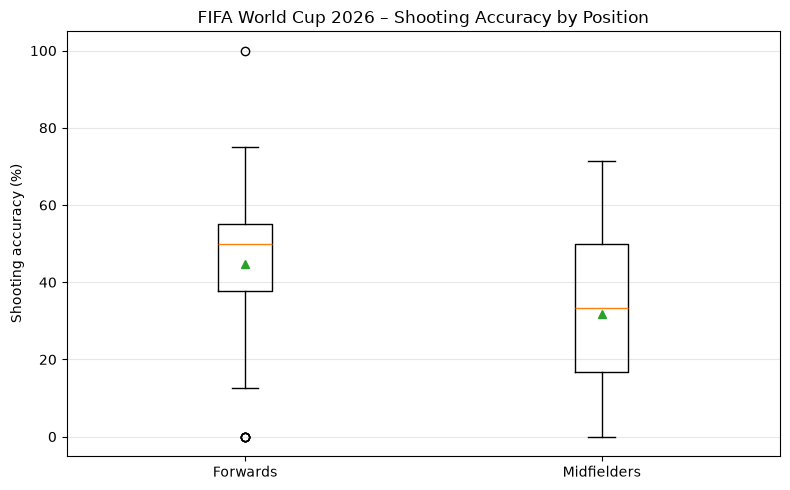

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = [
    task2_sample.loc[
        task2_sample["PrimaryPos"] == "FW", "ShootingAccuracy"
    ].dropna(),
    task2_sample.loc[
        task2_sample["PrimaryPos"] == "MF", "ShootingAccuracy"
    ].dropna()
]

ax.boxplot(plot_data, tick_labels=["Forwards", "Midfielders"], showmeans=True)
ax.set_title("FIFA World Cup 2026 – Shooting Accuracy by Position")
ax.set_ylabel("Shooting accuracy (%)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("task2_boxplot.png", dpi=200)
plt.show()


## 10. Interpretation

Use the numerical outputs generated above when presenting the task.

The main inferential decision is based on the **Welch two-sample t-test** at `alpha = 0.05`.

Report:
- the sample sizes;
- mean shooting accuracy for forwards and midfielders;
- 95% confidence interval for the mean difference;
- t statistic and p-value;
- the statistical decision;
- the football interpretation;
- relevant assumption/limitation comments.

A limitation is that shooting accuracy is affected by shot type, distance, defensive pressure and tactical role, which are not controlled in this analysis.
